# Burst detection and characterization

In this example, we demonstrate detection and characterization of beta (12-30 Hz), gamma (30-70 Hz) and high gamma (70-140 Hz) bursts in 2 channels from the left middle frontal gyrus (LMFG) and 2 channels from the left hippocampus (LH) of a single subject ("MU16").

In [1]:
import os, sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

# Set a fixation baseline
BASELINE = np.array([100, 900])

# Set frequency bands
BURST_FREQ_BANDS = {
    "beta": np.array([12, 30]),
    "gamma": np.array([30, 70]),
    "high_gamma": np.array([70, 140])
}

# In the sample data, LFP for each trial is stored across columns (see below)
LFP_COLS = [f"LFP_{k}" for k in range(6499)]

In [2]:
data = pd.read_csv(os.path.join("sample_data", "MU16.csv"))
data.head()

,patient,region,channel,trial_idx,LFP_0,LFP_1,LFP_2,LFP_3,LFP_4,LFP_5,...,LFP_6489,LFP_6490,LFP_6491,LFP_6492,LFP_6493,LFP_6494,LFP_6495,LFP_6496,LFP_6497,LFP_6498
0,MU16,LMFG,47,2,-60.586345,-61.003159,-56.932662,-49.502180,-57.041221,-50.611589,...,-22.416510,-19.159159,-31.267181,-24.738918,-36.600229,-32.127004,-28.065220,-26.732139,-31.661379,-21.543727
1,MU16,LMFG,47,3,70.637892,70.961432,60.612772,64.904897,61.675591,56.262496,...,-75.301535,-67.050140,-66.253000,-57.827647,-60.655502,-66.283112,-49.654750,-36.654182,-44.326227,-47.930041
2,MU16,LMFG,47,4,106.745603,95.213250,102.347220,94.459910,102.302446,93.481191,...,-3.919453,1.671527,3.907104,5.109215,4.066670,-6.005560,-9.228409,-4.949366,-10.088047,-11.581020
3,MU16,LMFG,47,5,-141.957212,-142.918853,-151.615530,-139.499856,-139.383692,-137.511779,...,-105.997811,-109.009809,-106.829899,-117.390465,-115.232323,-109.082471,-119.630475,-115.983875,-129.566979,-127.320677
4,MU16,LMFG,47,6,26.043050,41.416215,35.086903,36.075132,38.714519,39.923637,...,-78.135456,-80.281772,-72.660984,-69.412884,-61.186371,-61.112856,-64.577571,-58.155731,-60.150052,-54.026011


In [3]:
print(f"ROIs and channels:")
data[['region', 'channel']].drop_duplicates(ignore_index = True)

ROIs and channels:


,region,channel
0,LMFG,47
1,LMFG,60
2,LH,2
3,LH,10


## Burst detection

Bursts are time periods of elevated trial power for at least 3 oscillatory cycles. Consequently, burst detection requires the following components:
1. An `(n_trials, time)` matrix of trial power in the burst frequency band.
2. Power threshold specification:
   - A baseline period to with respect to which power elevation is computed
   - Degree of elevation (2 standard deviations by default).
3. Duration threshold specification: minimum duration (in ms; 3 cycles based on the mean of the burst frequency band by default).

In [4]:
from burst_toolbox.dsp import compute_power
from burst_toolbox.bursts import detect_bursts

In [17]:
# {burst_frequency_band: {channel: burst_matrix}}
bursts = {b_fb_name : {} for b_fb_name in BURST_FREQ_BANDS.keys()}

for b_fb_name, b_fb in BURST_FREQ_BANDS.items():
    for channel in data["channel"].unique():

        # Compute trial-by-trial power in the burst frequency band
        tbt_power = compute_power(
            LFP = data[data["channel"] == channel][LFP_COLS].to_numpy(),
            freq_band = b_fb
            )

        # Detect bursts
        bursts[b_fb_name][channel] = detect_bursts(
            power = tbt_power,
            reference_period = BASELINE,
            min_dur_ms = 3 * 1000 / np.mean(b_fb) # Duration threshold is based on the mean frequency over the burst freq. band
        )

We can now visualize burst rasters for different channels.

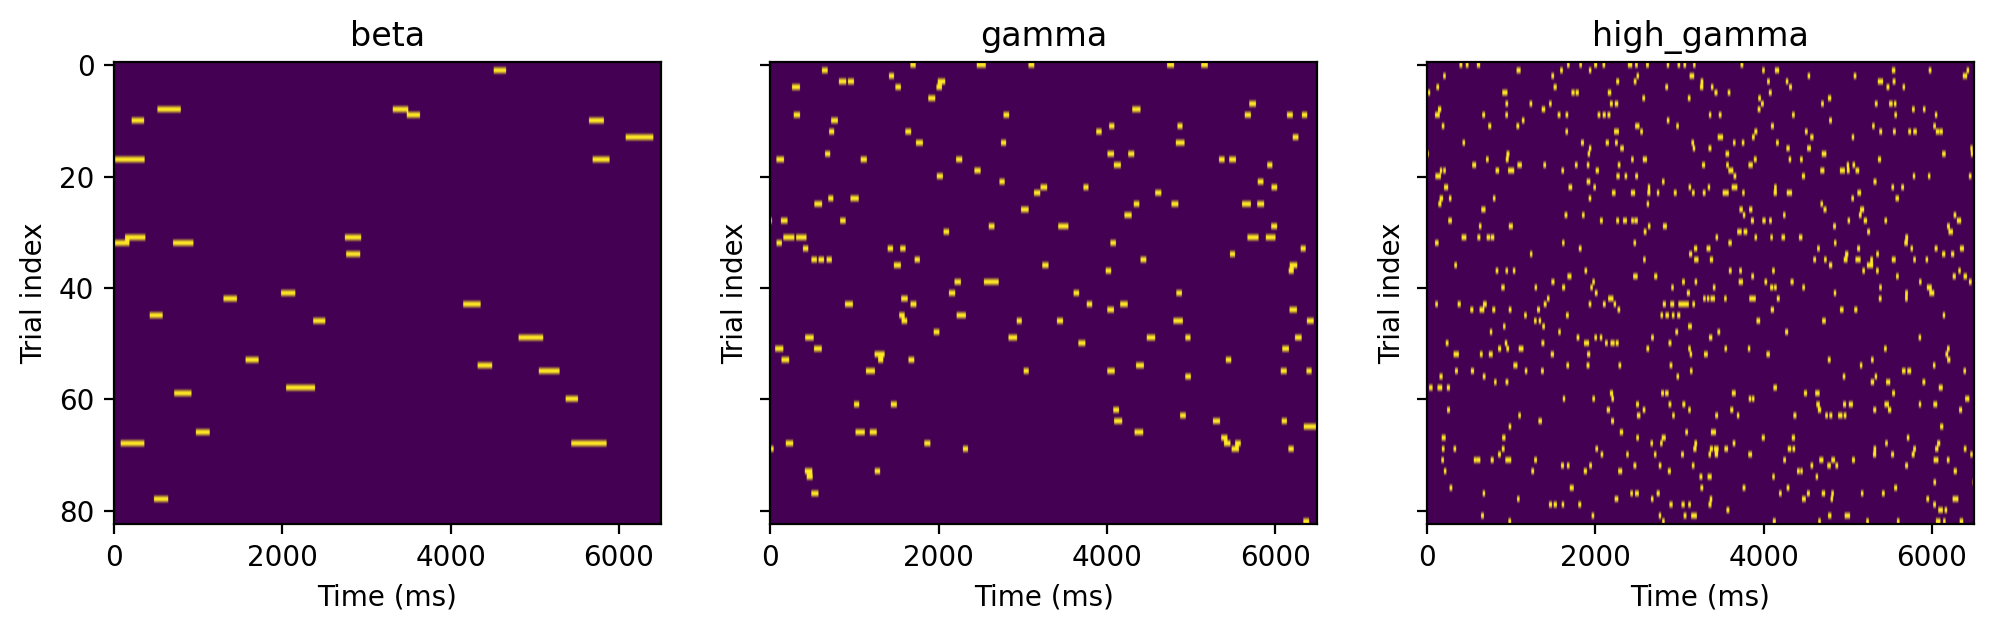

In [6]:
CHANNEL_TO_PLOT = 47

fig, ax = plt.subplots(1, 3, figsize = (12, 3), sharey = True, dpi = 200)

for col_id, b_fb_name in enumerate(BURST_FREQ_BANDS.keys()):
    ca = ax[col_id]
    ca.imshow(bursts[b_fb_name][CHANNEL_TO_PLOT], aspect = "auto", cmap = "viridis", interpolation = None)

    ca.set_xlabel("Time (ms)")
    ca.set_ylabel("Trial index")
    ca.set_title(b_fb_name)

## Burst characterization

The `make_burst_summary()` function computes
- burst_duration,
- inter-burst interval, 
- burst amplitude spread,
- burst frequency, 
- number of burst cycles

for each burst and generates a trial-level summary table with average characteristics.

In [7]:
from burst_toolbox.bursts import make_burst_summary

CHANNEL_TO_SUMMARIZE = 47
FREQ_BAND_TO_SUMMARIZE = "high_gamma"

In [11]:
summary_table, burst_level_data = make_burst_summary(
    bursts = bursts[FREQ_BAND_TO_SUMMARIZE][CHANNEL_TO_SUMMARIZE], 
    LFP = data[data["channel"] == CHANNEL_TO_SUMMARIZE][LFP_COLS].to_numpy(), 
    burst_freq_band = BURST_FREQ_BANDS[FREQ_BAND_TO_SUMMARIZE])

summary_table.head()

/Users/vladimiromelyusik/Burst-Toolbox/examples/../burst_toolbox/bursts.py:268: RuntimeWarning: Mean of empty slice
  burst_characteristics = np.nanmean(np.array(burst_characteristics), axis = 0)


,n_bursts,burst_rate_Hz,burst_duration,inter_burst_interval,burst_ampspr,burst_frequency,burst_n_cycles
0,15,2.308047,33.466667,204.571429,18.557585,88.181818,2.942424
1,8,1.230959,36.500000,725.000000,19.151023,88.446970,3.254545
2,7,1.077089,37.142857,992.333333,17.964323,86.796537,3.199134
3,7,1.077089,37.000000,508.833333,16.078827,89.177489,3.266667
4,8,1.230959,33.750000,755.428571,17.862999,88.446970,2.992045


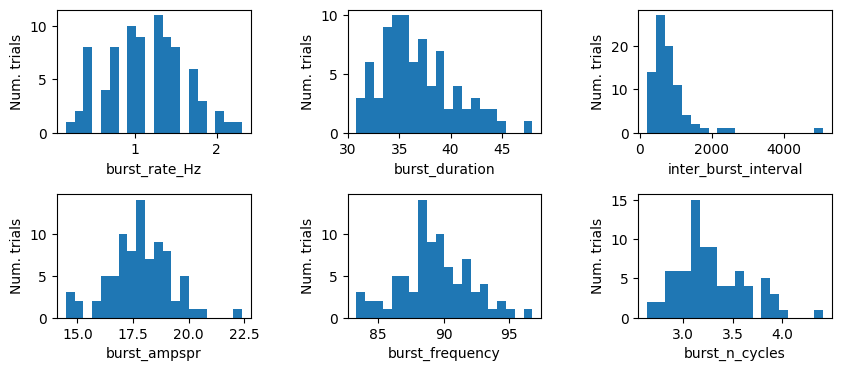

In [21]:
fig, ax = plt.subplots(2, 3, figsize = (10, 4))

for ax_id, burst_char in enumerate(summary_table.columns[1:]):
    ca = ax.flatten()[ax_id]
    ca.hist(summary_table[burst_char], bins = 20)
    ca.set_xlabel(burst_char)
    ca.set_ylabel("Num. trials")

plt.subplots_adjust(wspace = 0.5, hspace = 0.5)

## 1/trial burst rate

Despite bursts being single-trial events, the over-trial "1/trial" burst rate (Lundqvist et al., 2016, *Neuron*) shows task-relevant dynamics. The burst rate can be computed from the burst vectors directly as shown below.

In [ ]:
from burst_toolbox.stats import cluster_test_period

FREQ_BAND_TO_SUMMARIZE = "gamma"
CHANNELS_TO_SUMMARIZE = [47, 60] # LMFG

In [47]:
# Compute the burst rate per channel
burst_rate = []

for channel in CHANNELS_TO_SUMMARIZE:
    burst_rate_per_channel = np.mean(bursts[FREQ_BAND_TO_SUMMARIZE][channel], axis = 0)
    burst_rate.append(burst_rate_per_channel)

burst_rate = np.stack(burst_rate)
burst_rate.shape

(2, 6499)

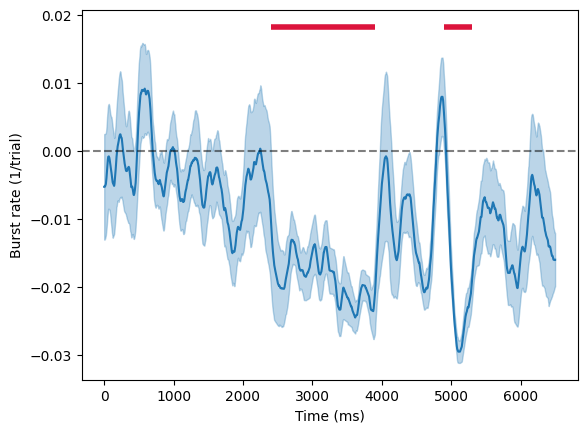

In [53]:
fig, ax = plt.subplots(1, 1)
ca = ax

# Baseline-correct
burst_rate = burst_rate - np.nanmean(burst_rate[:, BASELINE[0] : BASELINE[1]])

avg_burst_rate = np.nanmean(burst_rate, axis = 0)
sem_burst_rate = np.nanstd(burst_rate, axis = 0) / np.sqrt(len(burst_rate))
T = len(avg_burst_rate)

ca.plot(
    range(T), 
    uniform_filter1d(avg_burst_rate, 200),
    color = "tab:blue"
    )
ca.fill_between(
    range(T), 
    uniform_filter1d(avg_burst_rate - sem_burst_rate, 200), 
    uniform_filter1d(avg_burst_rate + sem_burst_rate, 200),
    color = "tab:blue",
    alpha = 0.3
    )

ca.set_xlabel("Time (ms)")
ca.set_ylabel("Burst rate (1/trial)")
ca.axhline(0, ls = "--", color = "black", alpha = 0.5)

# Cluster-test
step = 100
win_range = np.arange(0, len(LFP_COLS), step)
clusters = cluster_test_period(
    sample = burst_rate,
    period = BASELINE,
    win_range = win_range,
    win_size = 200
)

if len(clusters) > 0:
    yval = ca.get_ylim()[1]
    for tstat_id, period in enumerate(win_range):
        if (period < 100) or (period > 6200): continue
        if clusters[tstat_id] == 0: continue
        ca.hlines(yval, period, period + step, color = 'crimson', linewidth = 4)